In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from smbus2 import SMBus,i2c_msg
from scservo_sdk import *                    # Uses SCServo SDK library
import MCP342x
import logging

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from servodriver import Servoset
from servo_util import create_zigzag_X, a2p,xy2nd,ADS1115_fiber
from spiral import SpiralPath
from scipy.optimize import differential_evolution
from fit_gaussian import gaussian_2d,fit_and_plot,fit_gaussian_2d
import tqdm

Fiber channel reading: 13229
Time elapsed: 0.7288658618927002


In [7]:
servos = Servoset(servo_mask=None)
servos.servo_1x.set_acc(255)
servos.servo_1y.set_acc(255)
servos.servo_2x.set_acc(255)
servos.servo_2y.set_acc(255)
servos.servo_1x.set_speed(6000)
servos.servo_1y.set_speed(6000)
servos.servo_2x.set_speed(6000)
servos.servo_2y.set_speed(6000)

2024-09-17 13:37:30,035 - INFO - Succeeded to open the port
2024-09-17 13:37:30,059 - INFO - Succeeded to change the baudrate
2024-09-17 13:37:30,065 - INFO - Servo 1x: SCServo acc set!
2024-09-17 13:37:30,070 - INFO - Servo 1x: SCServo speed set!
2024-09-17 13:37:30,075 - ERROR - [RxPacketError] Input voltage error!
2024-09-17 13:37:30,076 - INFO - Servo 1y: SCServo acc set!
2024-09-17 13:37:30,081 - ERROR - Servo 1y: [RxPacketError] Input voltage error!
2024-09-17 13:37:30,082 - INFO - Servo 1y: SCServo speed set!
2024-09-17 13:37:30,087 - INFO - Servo 2x: SCServo acc set!
2024-09-17 13:37:30,092 - INFO - Servo 2x: SCServo speed set!
2024-09-17 13:37:30,098 - ERROR - [RxPacketError] Input voltage error!
2024-09-17 13:37:30,099 - INFO - Servo 2y: SCServo acc set!
2024-09-17 13:37:30,104 - ERROR - Servo 2y: [RxPacketError] Input voltage error!
2024-09-17 13:37:30,105 - INFO - Servo 2y: SCServo speed set!
2024-09-17 13:37:30,110 - INFO - Servo 1x: SCServo speed set!
2024-09-17 13:37:30,

In [8]:
X_Y_MASK = [0,0,1,1]
XDOT_YDOT_MASK = [1,1,0,0]
X_XDOT_MASK=[1,0,1,0]
Y_YDOT_MASK=[0,1,0,1]
#
servos.torques_enable()
servos.home()
ADS1115_fiber.value

2024-09-17 13:37:30,390 - ERROR - [RxPacketError] Input voltage error!
2024-09-17 13:37:30,400 - ERROR - [RxPacketError] Input voltage error!


13045

100%|██████████| 625/625 [01:33<00:00,  6.69it/s]


14047.0


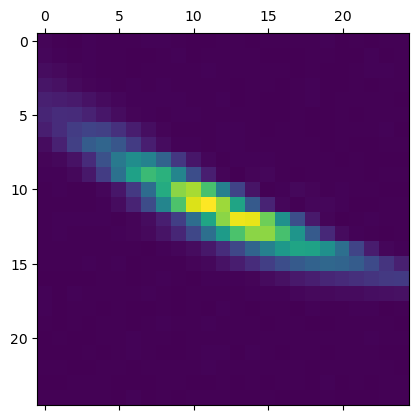

In [9]:
SCAN_RANGE=80
N_pts = 25
POS_MASK = X_XDOT_MASK
# POS_MASK = XDOT_YDOT_MASK
# POS_MASK = Y_YDOT_MASK
#
Xs = np.linspace(-SCAN_RANGE,SCAN_RANGE,N_pts)
Ys = np.linspace(-SCAN_RANGE,SCAN_RANGE,N_pts)
X,Y = np.meshgrid(Xs,Ys)
Z = np.zeros_like(X)
X_zig,index_map = create_zigzag_X(X)
servos.home()
dX = Xs[1]-Xs[0]
servos.set_precision(dX)
#

try:
    with tqdm.tqdm(total=len(Xs)*len(Ys)) as pbar:
        for i in range(len(Xs)):
            for j in range(len(Ys)):
                x,y = X_zig[i,j], Y[i,j]
                #
                idx = index_map[i,j] # original index of X
                idx_i, idx_j = np.unravel_index(idx, X.shape) # r[idx_i, idx_j] == r_zig[i,j]
                #
                # goal_position_list  = [px,a2p(0),py,a2p(0)]
                goal_position_list  = xy2nd(x,y,POS_MASK)
                #  
                servos.set_angle(goal_position_list)
                #
                data_cache = []
                for m in range(5):
                    data = ADS1115_fiber.value
                    data_cache.append(data)
                z = np.mean(np.array(data))
                #
                Z[idx_i,idx_j] = z
                pbar.update(1)

    # filename='/home/rydpiservo/servodata/20240913_2dscan.npz'
    # np.savez(filename, X=X,Y=Y,Z=Z)
except Exception as e:
    print(e)
finally:
    servos.home()
    servos.set_precision(1)
#
plt.matshow(Z)
# plt.contourf(X,Y,Z)
print(np.max(Z))
plt.show()

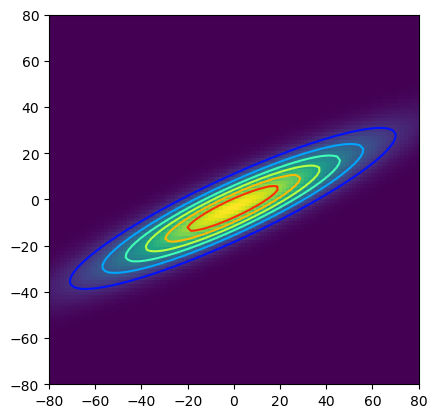

In [10]:
fit_and_plot(X,Y,Z)

In [6]:
def find_max_pos(Z):
    idx = np.argmax(Z)
    idx_i, idx_j = np.unravel_index(idx, Z.shape)
    return idx_i,idx_j
idx_x_max,idx_y_max = find_max_pos(Z)
print(f"Max position: {X[idx_x_max,idx_y_max],Y[idx_x_max,idx_y_max]}")
x_max = X[idx_x_max,idx_y_max]
y_max = Y[idx_x_max,idx_y_max]
px, py = a2p(X[idx_x_max,idx_y_max]), a2p(Y[idx_x_max,idx_y_max])
#
# servos.set_angle([px,a2p(0),py,a2p(0)])
pos_list = xy2nd(x_max,y_max,POS_MASK)
servos.set_angle(pos_list)
print(ADS1115_fiber.value)

Max position: (200.0, -57.14285714285714)
15900


In [8]:
servos.set_zero()

2024-09-16 16:38:37,616 - INFO - Set Zero Trail 1
2024-09-16 16:38:37,629 - INFO - Servo 1x: SCServo zero set!
2024-09-16 16:38:37,631 - INFO - Set Zero Trail 1
2024-09-16 16:38:37,667 - INFO - [TxRxResult] There is no status packet!
2024-09-16 16:38:37,674 - ERROR - Servo 1y: Read not sucessful!
2024-09-16 16:38:37,675 - INFO - Set Zero Trail 2
2024-09-16 16:38:37,676 - ERROR - [RxPacketError] Input voltage error!
2024-09-16 16:38:37,712 - INFO - Servo 1y: result [TxRxResult] Incorrect status packet!
2024-09-16 16:38:37,713 - INFO - Servo 1y: SCServo zero set!
2024-09-16 16:38:37,713 - INFO - Set Zero Trail 1
2024-09-16 16:38:37,749 - INFO - [TxRxResult] There is no status packet!
2024-09-16 16:38:37,759 - ERROR - Servo 2x: Read not sucessful!
2024-09-16 16:38:37,760 - INFO - Set Zero Trail 2
2024-09-16 16:38:37,796 - INFO - Servo 2x: result [TxRxResult] Incorrect status packet!
2024-09-16 16:38:37,796 - INFO - Servo 2x: SCServo zero set!
2024-09-16 16:38:37,797 - INFO - Set Zero Trai

In [30]:
servos.home()

In [16]:
from typing import List, Tuple, Callable,Union
from collections import deque
import scipy
import scipy.optimize

def plot_ion_position_transmission(
    uuid: str, callback_func: Callable, HIST_LENGTH: int = 1000, p0: List[float] = [0, 0], bounds: List[Tuple[float, float]] = [(-50, 50), (-50, 50)], method: str = "spiral"
):
    datas = deque(maxlen=HIST_LENGTH)  # [(x1,y1,T1), (x2,y2,T2), ...)]
    # >>> plot data <<<
    plt.ion()
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    # axs[0].set_xlabel("x(um)")
    # axs[0].set_ylabel("y(um)")
    boundx, boundy = bounds
    axs[0].set(xlim=boundx, ylim=boundy, xlabel="y(um)", ylabel="x(um)")
    axs[1].set_xlabel("time")
    axs[1].set_ylabel("transmission")
    # ax.set_ylim(0, 1)
    fig_new_pt = axs[0].scatter([], [], marker="x", c="black", s=50)
    fig_position = axs[0].scatter([], [], c=np.array([]), cmap="jet", vmin=0, vmax=1)
    (fig_transmission,) = axs[1].plot([], [])
    # print(aaa)
    # >>> update data <<<


    def _optimize_wrapper(datas, callback_func, paras,multiplier:int=1):
        # >>> update plot <<<
        if len(datas) > 0:
            xs, ys, es = zip(*datas)
            fig_position.set_offsets(np.column_stack((ys, xs)))
            fig_position.set_array(es)
            fig_position.set_alpha(
                np.linspace(0.2, 0.4, len(xs))
            )  # alpha increase with time
            #
            fig_transmission.set_data(range(len(es)), es)
            axs[1].relim()
            axs[1].autoscale_view()
        # highlight the new point
        fig_new_pt.set_offsets(np.column_stack((paras[1], paras[0])))
        x, y, T = callback_func(paras)
        # >>> update data <<<
        datas.append((x, y, T))
        #
        # fig.canvas.flush_events()
        #
        logging.debug(f"x: {x}, y: {y}, T: {T}")
        return multiplier*T

    #
    try:
        paras = p0
        if method == "L-BFGS-B":
            paras = scipy.optimize.minimize(
                lambda para: _optimize_wrapper(datas, callback_func, para, multiplier=-1),
                x0=p0,
                # method="Nelder-Mead",
                # method="Powell",
                method="L-BFGS-B",
                bounds=bounds,
                options={"disp": True, "maxiter": 10,  "eps": 1}
            )
            paras = paras.x 
        #
        elif method == "spiral":
        # use spiral path
            paras = sp.minimize(
                lambda para: _optimize_wrapper(datas, callback_func, para, multiplier=1),
                x0=paras,
                bounds=bounds,
            )
        #
        logging.info(f"Converged position: {paras}")
        #
        plt.ioff()
        # >>> plot datas <<<
        fig, ax = plt.subplots()
        xs, ys, es = zip(*datas)
        print(np.max(es))
        ax.scatter(
            ys, xs, c=es, cmap="jet", label="Visited points"
        )
        #
        xlst, ylst = paras
        ax.scatter(ylst, xlst, marker="x", c="black", s=50, label="Last point")  # type: ignore
        #
        xbst, ybst = datas[np.argmax(es)][:2]
        ax.scatter(ybst, xbst, marker="*", c="red", s=100, label="Best point")  # type: ignore
        #
        # plot x0 y0 trajectory
        if method == "spiral":
            pts_x0 = sp.pts_x0
            pts_y0 = sp.pts_y0
            ax.plot(pts_y0, pts_x0, "b--", label="(x0,y0)")
        #
        ax.set_xlim(boundx)
        ax.set_ylim(boundy)
        ax.set_xlabel("y(um)")
        ax.set_ylabel("x(um)")
        ax.legend()
        ax.set_aspect("equal")
        # colorbar to ax
        ax.figure.colorbar(ax.collections[0], ax=ax)
        # dataName = getDataName(uuid)
        # fileName = dataName + "_2D_align.png"
        # print(fileName)
        # plt.savefig(fileName, dpi=200, bbox_inches="tight")
        # plt.show()
        logging.info(f"Best position: x={xbst}, y={ybst}, I={np.max(es)}")
        return (xbst, ybst)

    except Exception as e:
        logging.error(e)

In [60]:
def callback_func(paras,pos_mask):
    x,y = paras
    goal_position_list  = xy2nd(x,y,pos_mask)
    servos.set_angle(goal_position_list)
    #
    data_cache = []
    for m in range(5):
        data = ADS1115_fiber.value
        data_cache.append(data)
    z = float(np.mean(np.array(data)))
    return x,y,z

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.34840D+04    |proj g|=  1.00000D+02


2024-09-17 11:13:58,347 - INFO - Converged position: [0. 0.]
2024-09-17 11:13:58,398 - INFO - Best position: x=0.0, y=0.0, I=13484.0



At iterate    1    f= -1.32270D+04    |proj g|=  1.00000D+02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    2      1     10      2     0     1   1.000D+02  -1.323D+04
  F =  -13227.000000000000     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
13484.0
Intensity: 13255


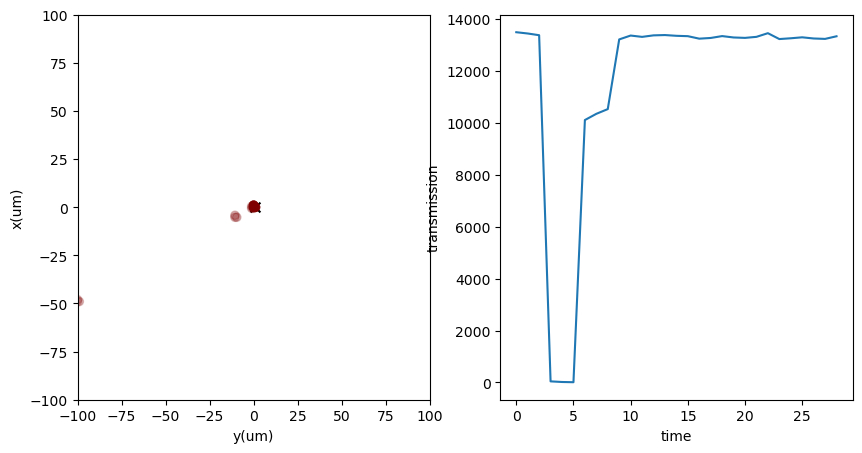

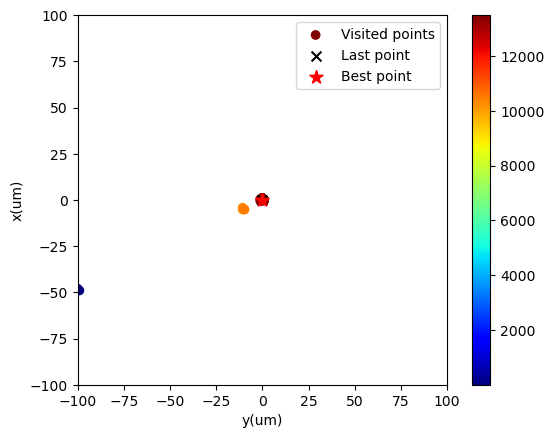

In [143]:
sp= SpiralPath()
sp.I_meaningful = 80
sp.D = 2
sp.SPIRAL_RESOLUTION=20
sp.SPIRAL_SPAN=10
sp.SINGLE_SPIRAL_SPAN=5
sp.N_LOOPS_BEFORE_RESET_ORIGIN = 0.5
sp.MAX_X0Y0_DISPLACEMENT = 10
sp.COEF_I_RESET_ORIGIN=1.4
sp._alpha = 0.03
sp.COEF_I_DECAY = 0.99
servos.set_precision(2)
#
bounds = [(-100,100),(-100,100)]
def combined_optimize(pos_mask,p0=None):
    x0,y0 = 0,0
    # x0,y0 = plot_ion_position_transmission("test", callback_func=lambda paras: callback_func(paras,pos_mask = pos_mask) ,p0=[0,0], bounds = bounds, method = "spiral")
    x0,y0 = plot_ion_position_transmission("test", callback_func=lambda paras: callback_func(paras,pos_mask = pos_mask), p0=[x0,y0], bounds = bounds, method = "L-BFGS-B")
    return x0,y0
#
try:
    # POS_MASK = X_Y_MASK
    # POS_MASK = XDOT_YDOT_MASK
    # POS_MASK = X_XDOT_MASK
    POS_MASK = Y_YDOT_MASK
    x0,y0 = combined_optimize(POS_MASK)
    pos_list = xy2nd(x0,y0,POS_MASK)
    servos.set_angle(pos_list)
    print(f"Intensity: {ADS1115_fiber.value}")
except Exception as e:
    servos.close()
    print(e)

In [100]:
servos.torques_disable()

2024-09-16 17:47:37,214 - ERROR - [RxPacketError] Input voltage error!
2024-09-16 17:47:37,233 - ERROR - [RxPacketError] Input voltage error!


In [144]:
servos.set_zero()
# servos.home()

2024-09-17 11:14:08,939 - INFO - Set Zero Trail 1
2024-09-17 11:14:08,977 - INFO - [TxRxResult] There is no status packet!
2024-09-17 11:14:08,984 - ERROR - Servo 1x: Read not sucessful!
2024-09-17 11:14:08,985 - INFO - Set Zero Trail 2
2024-09-17 11:14:09,021 - INFO - Servo 1x: result [TxRxResult] Incorrect status packet!
2024-09-17 11:14:09,022 - INFO - Servo 1x: SCServo zero set!
2024-09-17 11:14:09,023 - INFO - Set Zero Trail 1
2024-09-17 11:14:09,058 - INFO - [TxRxResult] There is no status packet!
2024-09-17 11:14:09,066 - ERROR - Servo 1y: Read not sucessful!
2024-09-17 11:14:09,066 - INFO - Set Zero Trail 2
2024-09-17 11:14:09,073 - ERROR - Servo 1y: Read not sucessful!
2024-09-17 11:14:09,073 - INFO - Set Zero Trail 3
2024-09-17 11:14:09,110 - INFO - Servo 1y: result [TxRxResult] Incorrect status packet!
2024-09-17 11:14:09,111 - INFO - Servo 1y: SCServo zero set!
2024-09-17 11:14:09,112 - INFO - Set Zero Trail 1
2024-09-17 11:14:09,121 - INFO - Servo 2x: SCServo zero set!
202